# Variant Analysis of the Hebrew Manuscripts of Ben Sira

In [2]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
words_count = {}
variations = {}
ratio_var = {}

In [4]:
def load_csv_files(directory):
    
    #Load all CSV files in a given directory and return them as a dictionary.
    
    dataframes = {}
    
    # Loop through all the files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(filepath)
            # Add the DataFrame to the dictionary with the filename as the key
            filename = filename.split('.')[0]
            dataframes[filename] = df
    
    return dataframes

In [5]:
directory = './data'  # Path to the directory where the CSVs are stored
dataframes = load_csv_files(directory)

In [6]:
"""
Words count
"""
# Loop on each data frame in each csv
for filename, df in dataframes.items():

    # select the name of columns "MS_" but excluding marginal notes "_mg"
    ms_columns = [col for col in df.columns if "MS_" in col and "_mg" not in col]

    words_count[filename] = {}
    words_count[filename]["words_ms_1"] = df[ms_columns[0]].notna().sum() #Number of words in col 1
    words_count[filename]["words_ms_2"] = df[ms_columns[1]].notna().sum() #Number of words in col 2
    words_count[filename]["words_alligned"] = df[df[ms_columns[0]].notna() & df[ms_columns[1]].notna()].shape[0] #number of aligned words
    words_count[filename]["Words_not_alligned"] = df[(df[ms_columns[1]].notna() & df[ms_columns[0]].isna()) | (df[ms_columns[0]].notna() & df[ms_columns[1]].isna())].shape[0] #number of words not aligned
    

    
    variants = df.groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category

    #Calculate the percentage of each category in relation to the number of aligned and non-aligned words
    for variant in variants:
        words_count[filename][variant] = variants[variant]# * 100 / (words_count[filename]["words_alligned"] + words_count[filename]["Words_not_alligned"])

pd.DataFrame.from_dict(words_count).round(1).T.fillna("")

,words_ms_1,words_ms_2,words_alligned,Words_not_alligned,Lexical,Morphological,Plus_Minus,Same,Unclassifiable,Inversion
MSS_M_Bmg,885.0,219.0,179.0,746.0,33.0,39.0,1.0,67.0,7.0,
MSS_C_D,113.0,125.0,109.0,20.0,10.0,11.0,17.0,61.0,29.0,6.0
MSS_A_D,330.0,266.0,260.0,76.0,1.0,8.0,1.0,181.0,104.0,
MSS_D_Bmg,264.0,103.0,102.0,163.0,10.0,16.0,1.0,74.0,1.0,
MSS_A_B,508.0,511.0,491.0,37.0,18.0,33.0,94.0,295.0,80.0,4.0
MSS_E_F,114.0,114.0,114.0,0.0,,2.0,,58.0,28.0,
MSS_A_C,399.0,431.0,370.0,90.0,69.0,49.0,51.0,233.0,6.0,6.0
MSS_B_F,298.0,267.0,247.0,71.0,23.0,20.0,47.0,153.0,56.0,2.0
MSS_B_E,122.0,119.0,118.0,5.0,11.0,6.0,10.0,44.0,26.0,
MSS_B_D,255.0,255.0,249.0,12.0,42.0,38.0,20.0,152.0,4.0,4.0


## Ratio of Variances by Manuscript Pairs

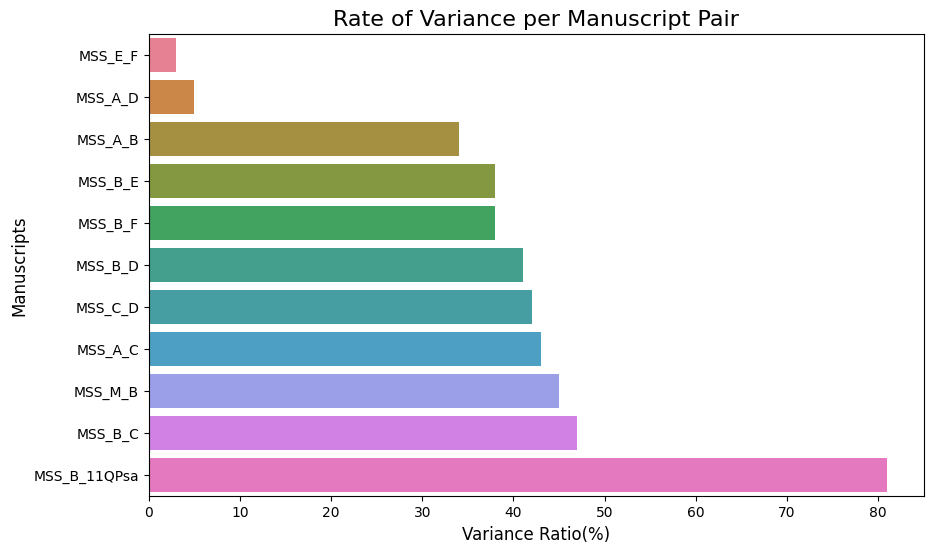

In [7]:
"""
Ratio of variations
"""
# Loop on each data frame in each csv
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']
    
    variations[filename] = {}

    variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
    same = df[df['Categories'] == 'Same'].shape[0]
    ratio = variants * 100 / (variants+same)
    variations[filename]=[ratio]

df = pd.DataFrame.from_dict(variations).round(0).T.sort_index(ascending=True)
df.columns = ["ratio"]
df = df.sort_values(by="ratio", ascending=True) #Sort by Value
df = df[~df.index.str.contains('mg')] #delete all mg 

# Créer le barplot horizontal
plt.figure(figsize=(10, 6))
#sns.set(style="whitegrid")
palette = sns.color_palette("pastel", as_cmap=False)

# Trace un barplot horizontal
sns.barplot(x="ratio", y=df.index, data=df, hue=df.index, dodge=False)

# Ajouter un titre et des labels
plt.title("Rate of Variance per Manuscript Pair", fontsize=16)
plt.xlabel("Variance Ratio(%)", fontsize=12)
plt.ylabel("Manuscripts", fontsize=12)

# Afficher le graphique
plt.show()



## Variation Rates by Categories

<Axes: >

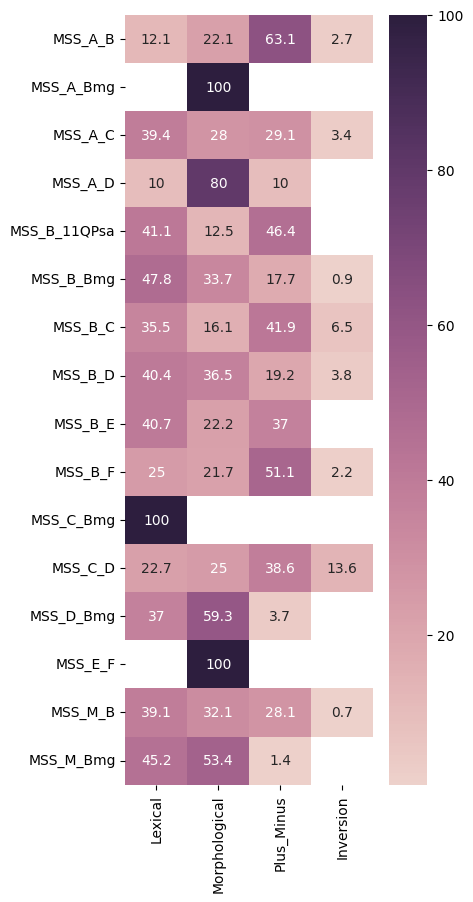

In [8]:
"""
Variation rates on categories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']

    ratio_var[filename] = {}
    
    variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
    total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
    #print(f"{filename} : {variants} - total variants {total_variants}")
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants

table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
plt.figure(figsize=(4, 10))
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')


## Variation Rates by Subcategories

<Axes: >

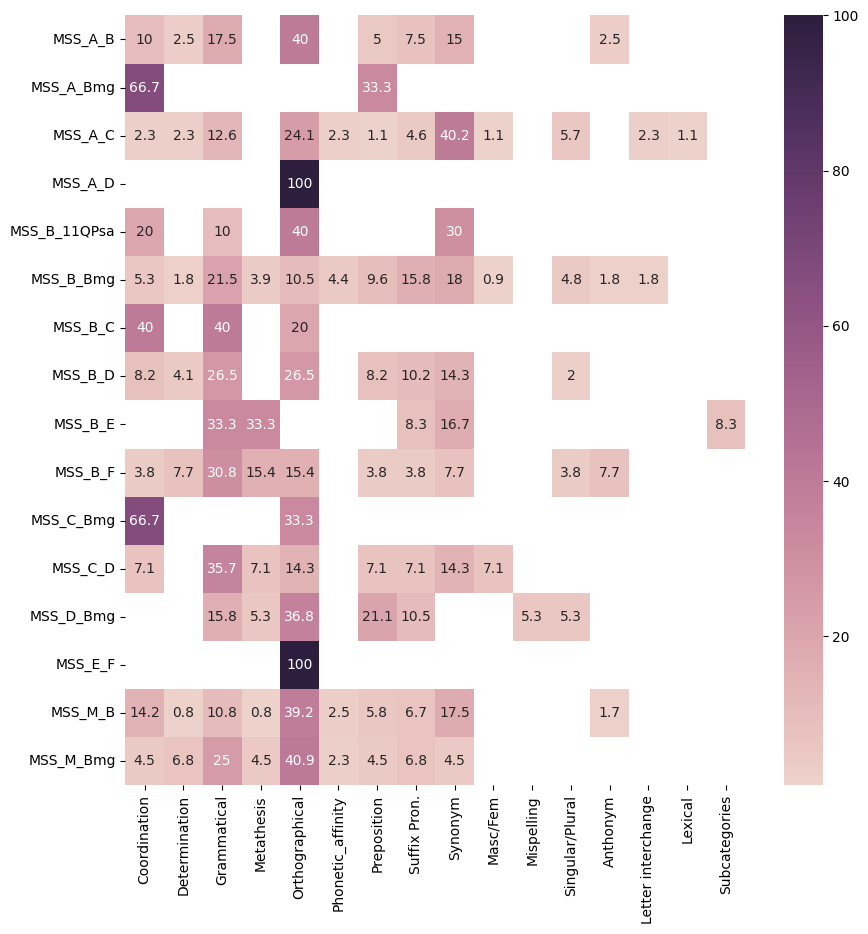

In [9]:
"""
Variation rates by subcategories
"""
for filename, df in dataframes.items():

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']
 
    ratio_var[filename] = {}
    
    variants = df.groupby('Subcategories_1').size().to_dict() # Create a dictionary of the number of item in each category
    total_variants = df.groupby('Subcategories_1').size().sum()
    #print(f"{filename} : {variants} - total variants {total_variants}")
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants
        

#pd.set_option('display.float_format', lambda x: 'd' % x)
table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
plt.figure(figsize=(10, 10))
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    

# Collatex allignment of Sir 37:1 (MSS B, Bmg, C and D)

+-----+----+------+------+------+-------+
| B   | כל | -    | אומר | אמר  | אהבתי |
| Bmg | כל | אוהב | אומר | -    | אהבתי |
| C   | כל | אוהב | -    | יאמר | אהבתו |
| D   | כל | אוהב | אומר | -    | אהבתי |
+-----+----+------+------+------+-------+


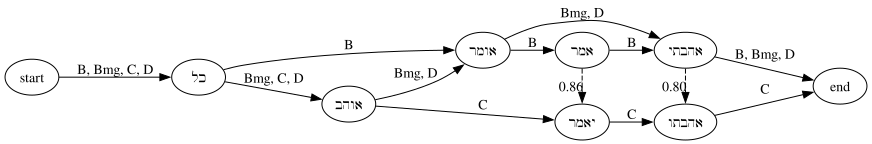

In [11]:
from collatex import *

dataset = {
    37: {
        1: {
            "B": "כל אומר אמר אהבתי",
            "Bmg":"כל אוהב אומר אהבתי",
            "C":"כל אוהב יאמר אהבתו",
            "D":"כל אוהב אומר אהבתי"
        }
    }
}

collation = Collation()
for mss in dataset[37][1].items():
    collation.add_plain_witness(mss[0], mss[1])

alligment_table = collate(collation, near_match=True, segmentation=False)
print(alligment_table)
alligment_table_svg = collate(collation, near_match=True, segmentation=False, output = "svg_simple")

# DictaBert - Morphological Analysis of Sir 37:1

In [25]:
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('dicta-il/dictabert-morph')
model = AutoModel.from_pretrained('dicta-il/dictabert-morph', trust_remote_code=True)
model.eval()
je chfor mss in dataset[37][1].items():
    morph = model.predict([mss[1]], tokenizer)
    morph = json.dumps(morph, indent=2, ensure_ascii=False)
    print(f"Morphological Analysis of {mss[0]} : {morph}")

Morphological Analysis of B : [
  {
    "text": "כל אומר אמר אהבתי",
    "tokens": [
      {
        "token": "כל",
        "pos": "DET",
        "feats": {},
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אומר",
        "pos": "VERB",
        "feats": {
          "Gender": "Masc",
          "Number": "Sing",
          "Person": "1,2,3"
        },
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אמר",
        "pos": "VERB",
        "feats": {
          "Gender": "Masc",
          "Number": "Sing",
          "Person": "3",
          "Tense": "Past"
        },
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אהבתי",
        "pos": "NOUN",
        "feats": {
          "Gender": "Fem",
          "Number": "Sing"
        },
        "prefixes": [],
        "suffix": "ADP_PRON",
        "suffix_feats": {
          "Gender": "Fem,Masc",
          "Number": "Sing",
          "Person": "1"
   